# IF3270 Machine Learning
# CNN Training with Keras
## End-to-End Training Pipeline

This notebook focuses on:
- validating the image processing utility functions
- loading the image classification dataset in a reproducible way without data leakage
- training 16 shared-parameter CNN architectures with Keras
- saving model weights, model files, and training artifacts

Group Number: 69

Group Members:
- Mochammad Fariz Rifqi Rizqulloh (13523069)
- Muhammad Jibril Ibrahim (13523085)
- Nayaka Ghana Subrata (13523090)

## 0. Runtime Notes

Run this notebook from the repository `.venv` and through WSL.
The main outputs are `.keras` models, model weights, training history, summary metrics, and experiment result tables.

---
# 1. Setup

### 1.1 Environment Setup

This section resolves the repository root, adds the project source directory to `sys.path`, and prepares the TensorFlow GPU environment.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from common import configure_tensorflow_gpu

GPU_ENV = configure_tensorflow_gpu()

### 1.2 Import Libraries

All notebook imports are grouped here after the environment has been prepared.

In [2]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import tensorflow as tf

from cnn import (
    build_cnn_classifier,
    build_experiment_grid,
    extract_and_save_features,
    format_model_architecture,
    load_image,
    load_image_batch,
    load_image_classification_dataset,
    load_saved_classifier,
    resolve_dataset_root,
    save_dataset_manifest,
    set_random_seed,
    summarize_model_layers,
    train_experiment,
)
from cnn.training import summarize_experiments

I0000 00:00:1778771104.127333    1060 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 1.3 Experiment Configuration

The configuration below defines the random seed, image size, batch size, training epochs, and artifact locations.

In [3]:
SEED = 42
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)
BATCH_SIZE = 4
EPOCHS = 6
LEARNING_RATE = 1e-3

DATASET_ROOT = resolve_dataset_root()
ARTIFACTS_DIR = REPO_ROOT / "artifacts" / "cnn"
SHARED_OUTPUT_DIR = ARTIFACTS_DIR / "shared"
REPORTS_DIR = ARTIFACTS_DIR / "reports"
MANIFEST_PATH = REPO_ROOT / "data" / "processed" / "cnn" / "dataset_manifest.json"
FEATURE_DEMO_PATH = REPORTS_DIR / "demo_encoder_features.npy"

RUN_SHARED_SWEEP = True
REUSE_EXISTING_ARTIFACTS = True

In [4]:
set_random_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.optimizer.set_jit(False)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("TensorFlow:", tf.__version__)
print("Available GPUs:", gpus)
print("LD_LIBRARY_PATH:", GPU_ENV["LD_LIBRARY_PATH"])
print("LD_PRELOAD:", GPU_ENV["LD_PRELOAD"])

TensorFlow: 2.21.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
LD_LIBRARY_PATH: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/cublas/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/cuda_cupti/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/cuda_runtime/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/cudnn/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/cufft/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/curand/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/nvidia/cusolver/lib:/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.v

---
# 2. Data Utilities

This part validates the required utility functions:
- image loader
- batch loader
- feature extractor that saves `.npy` files

### 2.1 Dataset Loading

The dataset is loaded with a reproducible split policy. If a dedicated validation directory does not exist, the validation split is derived from the training split only.

In [5]:
dataset = load_image_classification_dataset(
    dataset_root=DATASET_ROOT,
    validation_split=0.2,
    random_state=SEED,
)
save_dataset_manifest(dataset, MANIFEST_PATH)

print("Dataset root:", DATASET_ROOT)
print("Train:", dataset.train.size)
print("Val:", dataset.val.size)
print("Test:", dataset.test.size)
print("Classes:", dataset.class_names)

Dataset root: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/data/raw/intel
Train: 11227
Val: 2807
Test: 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### 2.2 Image Loader and Batch Loader Check

The following cells verify that a single image and a batch of images are loaded correctly, resized to the target size, and normalized to the `[0, 1]` range.

Single image shape: (224, 224, 3) float32 0.0 1.0
Batch shape: (4, 224, 224, 3)


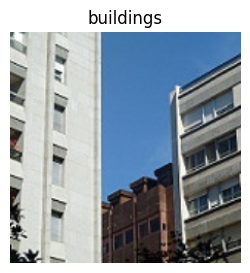

In [6]:
sample_paths = dataset.train.image_paths[:4]
sample_image = load_image(sample_paths[0], target_size=IMAGE_SIZE)
sample_batch = load_image_batch(sample_paths, target_size=IMAGE_SIZE)

print("Single image shape:", sample_image.shape, sample_image.dtype, sample_image.min(), sample_image.max())
print("Batch shape:", sample_batch.shape)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(Path(sample_paths[0]).parent.name)
plt.axis("off")
plt.show()

### 2.3 Split Size Summary

This table provides a quick overview of the number of samples in each split.

In [7]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "size": [dataset.train.size, dataset.val.size, dataset.test.size],
    }
)
split_summary

,split,size
0,train,11227
1,val,2807
2,test,3000


### 2.4 Class Distribution Across Splits

Class counts are shown for the training, validation, and test splits to ensure the data distribution is reasonable and to check for any obvious imbalance.

In [8]:
def count_labels(split):
    counts = np.bincount(split.labels, minlength=dataset.num_classes)
    return pd.Series(counts, index=dataset.class_names, name=split.name)

class_distribution = pd.concat(
    [count_labels(dataset.train), count_labels(dataset.val), count_labels(dataset.test)],
    axis=1,
)
class_distribution

,train,val,test
buildings,1753,438,437
forest,1817,454,474
glacier,1923,481,553
mountain,2009,503,525
sea,1819,455,510
street,1906,476,501


---
# 3. Data Preprocessing and Reproducibility

The validation split is created from the training split when a separate validation directory is not available.
The test split remains a holdout split, so there is no leakage from training into evaluation.

### 3.1 Reproducibility Policy

The configuration summary below is saved so the training setup can be reproduced consistently.

In [9]:
dataset_info = {
    "dataset_root": str(DATASET_ROOT),
    "seed": SEED,
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "train_size": dataset.train.size,
    "val_size": dataset.val.size,
    "test_size": dataset.test.size,
    "class_names": dataset.class_names,
}
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
(REPORTS_DIR / "dataset_info.json").write_text(json.dumps(dataset_info, indent=2) + "\n", encoding="utf-8")
dataset_info

{'dataset_root': '/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/data/raw/intel',
 'seed': 42,
 'image_size': [224, 224],
 'batch_size': 4,
 'epochs': 6,
 'train_size': 11227,
 'val_size': 2807,
 'test_size': 3000,
 'class_names': ['buildings',
  'forest',
  'glacier',
  'mountain',
  'sea',
  'street']}

---
# 4. Shared CNN Architecture Search

The architecture sweep uses:
- 2 variations for the number of convolutional layers
- 2 filter-count combinations
- 2 kernel-size combinations
- 2 pooling variants

Total: `2 x 2 x 2 x 2 = 16` architectures.

### 4.1 Experiment Grid

Each configuration corresponds to one shared-parameter CNN architecture that will be trained and evaluated with the same optimization setup.

In [10]:
experiment_configs = build_experiment_grid(
    layer_counts=[2, 3],
    filter_variants=[16, 24],
    kernel_variants=[(3, 3), (5, 5)],
    pooling_types=["max", "avg"],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    input_shape=INPUT_SHAPE,
    dense_units=(64,),
    use_global_pooling=False,
)

experiment_table = pd.DataFrame(
    [
        {
            "name": config.name,
            "layers": len(config.conv_filters),
            "filters": config.conv_filters,
            "kernels": config.kernel_sizes,
            "pooling": config.pooling_type,
        }
        for config in experiment_configs
    ]
)
experiment_table

,name,layers,filters,kernels,pooling
0,cnn_l2_f16-16_k3x3-3x3_max,2,"(16, 16)","((3, 3), (3, 3))",max
1,cnn_l2_f16-16_k3x3-3x3_avg,2,"(16, 16)","((3, 3), (3, 3))",avg
2,cnn_l2_f16-16_k5x5-5x5_max,2,"(16, 16)","((5, 5), (5, 5))",max
3,cnn_l2_f16-16_k5x5-5x5_avg,2,"(16, 16)","((5, 5), (5, 5))",avg
4,cnn_l2_f24-24_k3x3-3x3_max,2,"(24, 24)","((3, 3), (3, 3))",max
5,cnn_l2_f24-24_k3x3-3x3_avg,2,"(24, 24)","((3, 3), (3, 3))",avg
6,cnn_l2_f24-24_k5x5-5x5_max,2,"(24, 24)","((5, 5), (5, 5))",max
7,cnn_l2_f24-24_k5x5-5x5_avg,2,"(24, 24)","((5, 5), (5, 5))",avg
8,cnn_l3_f16-16-16_k3x3-3x3-3x3_max,3,"(16, 16, 16)","((3, 3), (3, 3), (3, 3))",max
9,cnn_l3_f16-16-16_k3x3-3x3-3x3_avg,3,"(16, 16, 16)","((3, 3), (3, 3), (3, 3))",avg


### 4.2 Complete Architecture Definitions

Each architecture is printed in a `Sequential.add(...)` style so the layer order and arguments are explicit.
Note that `ReLU` may appear inside `Conv2D(..., activation='relu')` or `Dense(..., activation='relu')`.
In that case, Keras does not create a separate `ReLU` layer because the activation is defined inline.
A separate activation layer is shown only when the model explicitly contains `tf.keras.layers.ReLU`, `Softmax`, or `Activation`.

In [11]:
architecture_text = {}

for config in experiment_configs:
    architecture_model = build_cnn_classifier(
        input_shape=config.input_shape,
        num_classes=dataset.num_classes,
        conv_filters=config.conv_filters,
        kernel_sizes=config.kernel_sizes,
        pooling_type=config.pooling_type,
        dense_units=config.dense_units,
        use_global_pooling=config.use_global_pooling,
        conv_padding=config.conv_padding,
        activation=config.activation,
        local_connectivity=config.local_connectivity,
        name=config.name,
    )
    architecture_text[config.name] = format_model_architecture(architecture_model)

for model_name, model_code in architecture_text.items():
    print("=" * 100)
    print(model_name)
    print(model_code)
    print()

I0000 00:00:1778771248.934550    1060 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3367 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


cnn_l2_f16-16_k3x3-3x3_max
classifier = tf.keras.Sequential(name="cnn_l2_f16-16_k3x3-3x3_max")
classifier.add(tf.keras.layers.Conv2D(16, (3, 3), input_shape=(224, 224, 3), padding='same', activation='relu'))
classifier.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
classifier.add(tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
classifier.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
classifier.add(tf.keras.layers.Flatten())
classifier.add(tf.keras.layers.Dense(64, activation='relu'))
classifier.add(tf.keras.layers.Dense(6, activation='softmax'))

cnn_l2_f16-16_k3x3-3x3_avg
classifier = tf.keras.Sequential(name="cnn_l2_f16-16_k3x3-3x3_avg")
classifier.add(tf.keras.layers.Conv2D(16, (3, 3), input_shape=(224, 224, 3), padding='same', activation='relu'))
classifier.add(tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)))
classifier.add(tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
clas

### 4.3 Architecture Preview

Before running the full sweep, one representative configuration is built and inspected to confirm the layer arrangement and trainable parameter count.

In [12]:
preview_config = experiment_configs[0]
preview_model = build_cnn_classifier(
    input_shape=preview_config.input_shape,
    num_classes=dataset.num_classes,
    conv_filters=preview_config.conv_filters,
    kernel_sizes=preview_config.kernel_sizes,
    pooling_type=preview_config.pooling_type,
    dense_units=preview_config.dense_units,
    use_global_pooling=preview_config.use_global_pooling,
    conv_padding=preview_config.conv_padding,
    activation=preview_config.activation,
    local_connectivity=preview_config.local_connectivity,
    name=preview_config.name,
)
preview_model.summary()

Model: "cnn_l2_f16-16_k3x3-3x3_max"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv (Conv2D)            │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 112, 112, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,214,486 (12.26 MB)

 Trainable params: 3,214,486 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
preview_layers_df = pd.DataFrame(summarize_model_layers(preview_model))
preview_layers_df

,name,type,trainable,params,filters,kernel_size,pool_size,strides,padding,units,activation
0,block1_conv,Conv2D,True,448,16.0,"(3, 3)",None,"(1, 1)",same,NaN,relu
1,block1_pool,MaxPooling2D,True,0,NaN,None,"(2, 2)","(2, 2)",valid,NaN,None
2,block2_conv,Conv2D,True,2320,16.0,"(3, 3)",None,"(1, 1)",same,NaN,relu
3,block2_pool,MaxPooling2D,True,0,NaN,None,"(2, 2)","(2, 2)",valid,NaN,None
4,flatten,Flatten,True,0,NaN,None,None,None,None,NaN,None
5,dense_1,Dense,True,3211328,NaN,None,None,None,None,64.0,relu
6,classifier,Dense,True,390,NaN,None,None,None,None,6.0,softmax


In [14]:
print("Trainable params:", preview_model.count_params())

Trainable params: 3214486


---
# 5. Shared CNN Training

This stage trains all shared-parameter architectures and saves their weights, full model files, training history, and summary metrics.

### 5.1 Training Loop

Set `RUN_SHARED_SWEEP = True` to execute the 16-model training sweep. If artifacts already exist, they can be reused to avoid repeating completed runs.

In [15]:
SHARED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if RUN_SHARED_SWEEP:
    for config in experiment_configs:
        summary_path = SHARED_OUTPUT_DIR / f"{config.name}_summary.json"
        if REUSE_EXISTING_ARTIFACTS and summary_path.exists():
            print(f"Skipping existing model: {config.name}")
            continue

        print(f"Training {config.name}")
        train_experiment(
            config=config,
            train_split=dataset.train,
            val_split=dataset.val,
            num_classes=dataset.num_classes,
            output_dir=SHARED_OUTPUT_DIR,
        )
else:
    print("Set RUN_SHARED_SWEEP = True to train all 16 shared-parameter CNN models.")

Skipping existing model: cnn_l2_f16-16_k3x3-3x3_max


Skipping existing model: cnn_l2_f16-16_k3x3-3x3_avg
Skipping existing model: cnn_l2_f16-16_k5x5-5x5_max
Skipping existing model: cnn_l2_f16-16_k5x5-5x5_avg
Skipping existing model: cnn_l2_f24-24_k3x3-3x3_max
Skipping existing model: cnn_l2_f24-24_k3x3-3x3_avg
Skipping existing model: cnn_l2_f24-24_k5x5-5x5_max
Skipping existing model: cnn_l2_f24-24_k5x5-5x5_avg
Skipping existing model: cnn_l3_f16-16-16_k3x3-3x3-3x3_max
Skipping existing model: cnn_l3_f16-16-16_k3x3-3x3-3x3_avg
Skipping existing model: cnn_l3_f16-16-16_k5x5-5x5-5x5_max
Skipping existing model: cnn_l3_f16-16-16_k5x5-5x5-5x5_avg
Skipping existing model: cnn_l3_f24-24-24_k3x3-3x3-3x3_max
Skipping existing model: cnn_l3_f24-24-24_k3x3-3x3-3x3_avg


Skipping existing model: cnn_l3_f24-24-24_k5x5-5x5-5x5_max


Skipping existing model: cnn_l3_f24-24-24_k5x5-5x5-5x5_avg


---
# 6. Training Results and Model Selection

After training, the saved summaries are collected into a single table and ranked by validation macro F1-score.

### 6.1 Experiment Result Table

This table is the main comparison view for the 16 shared CNN architectures.

In [16]:
summary_paths = sorted(SHARED_OUTPUT_DIR.glob("*_summary.json"))
summaries = summarize_experiments(summary_paths)

if summaries:
    results_df = pd.DataFrame(
        [
            {
                "name": item["config"]["name"],
                "layers": len(item["config"]["conv_filters"]),
                "filters": tuple(item["config"]["conv_filters"]),
                "kernels": tuple(tuple(kernel) for kernel in item["config"]["kernel_sizes"]),
                "pooling": item["config"]["pooling_type"],
                "val_loss": item["validation_metrics"]["loss"],
                "val_accuracy": item["validation_metrics"]["accuracy"],
                "val_macro_f1": item["validation_metrics"]["macro_f1"],
                "params": item["parameter_count"],
                "best_epoch": item["best_epoch"],
            }
            for item in summaries
        ]
    ).sort_values("val_macro_f1", ascending=False)
else:
    results_df = pd.DataFrame()
    print("No training summaries found yet.")

results_df

,name,layers,filters,kernels,pooling,val_loss,val_accuracy,val_macro_f1,params,best_epoch
12,cnn_l3_f24-24-24_k3x3-3x3-3x3_avg,3,"(24, 24, 24)","((3, 3), (3, 3), (3, 3))",avg,0.659108,0.775561,0.776496,1215766,3
13,cnn_l3_f24-24-24_k3x3-3x3-3x3_max,3,"(24, 24, 24)","((3, 3), (3, 3), (3, 3))",max,0.835253,0.766655,0.767425,1215766,4
8,cnn_l3_f16-16-16_k3x3-3x3-3x3_avg,3,"(16, 16, 16)","((3, 3), (3, 3), (3, 3))",avg,0.776668,0.762024,0.764288,808358,4
9,cnn_l3_f16-16-16_k3x3-3x3-3x3_max,3,"(16, 16, 16)","((3, 3), (3, 3), (3, 3))",max,1.061295,0.752761,0.753414,808358,5
15,cnn_l3_f24-24-24_k5x5-5x5-5x5_max,3,"(24, 24, 24)","((5, 5), (5, 5), (5, 5))",max,0.775718,0.747417,0.748608,1235350,3
11,cnn_l3_f16-16-16_k5x5-5x5-5x5_max,3,"(16, 16, 16)","((5, 5), (5, 5), (5, 5))",max,0.944949,0.748130,0.747970,817318,4
5,cnn_l2_f24-24_k3x3-3x3_max,2,"(24, 24)","((3, 3), (3, 3))",max,0.783844,0.746348,0.747918,4823230,2
14,cnn_l3_f24-24-24_k5x5-5x5-5x5_avg,3,"(24, 24, 24)","((5, 5), (5, 5), (5, 5))",avg,1.287300,0.742073,0.741865,1235350,6
10,cnn_l3_f16-16-16_k5x5-5x5-5x5_avg,3,"(16, 16, 16)","((5, 5), (5, 5), (5, 5))",avg,0.892486,0.738867,0.740460,817318,5
7,cnn_l2_f24-24_k5x5-5x5_max,2,"(24, 24)","((5, 5), (5, 5))",max,0.945574,0.726042,0.725501,4833598,3


### 6.2 Validation Macro F1 Comparison

A bar chart is used to compare validation macro F1 across the available architectures.

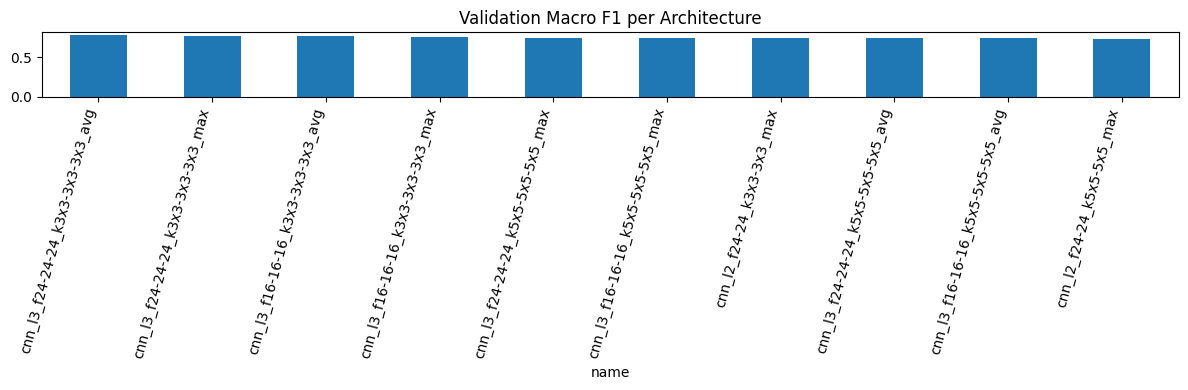

In [17]:
if not results_df.empty:
    results_df.head(10).plot.bar(
        x="name",
        y="val_macro_f1",
        figsize=(12, 4),
        legend=False,
        title="Validation Macro F1 per Architecture",
    )
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

### 6.3 Training Curves for the Best Shared Model

The best shared model is inspected through loss and macro F1 curves to understand its optimization behavior.

In [18]:
def load_history(history_path):
    with open(history_path, "r", encoding="utf-8") as file:
        return json.load(file)

def plot_history(history_path, title):
    history = load_history(history_path)
    epochs = range(1, len(history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["macro_f1"], label="train")
    axes[1].plot(epochs, history["val_macro_f1"], label="val")
    axes[1].set_title(f"{title} - Macro F1")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def plot_loss_grid(model_names, history_dir, title_prefix, cols=2):
    if not model_names:
        print("No models provided.")
        return

    rows = int(np.ceil(len(model_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    axes = np.atleast_1d(axes).reshape(rows, cols)

    for axis in axes.flat:
        axis.axis("off")

    for axis, model_name in zip(axes.flat, model_names):
        history_path = history_dir / f"{model_name}_history.json"
        if not history_path.exists():
            axis.set_title(f"{model_name}\nmissing history")
            continue

        history = load_history(history_path)
        epochs = range(1, len(history["loss"]) + 1)
        axis.axis("on")
        axis.plot(epochs, history["loss"], label="train")
        axis.plot(epochs, history["val_loss"], label="val")
        axis.set_title(model_name)
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Loss")
        axis.legend(fontsize=8)

    fig.suptitle(title_prefix, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [19]:
def summarize_factor(results_df, column):
    summary = (
        results_df.groupby(column, dropna=False)
        .agg(
            mean_val_macro_f1=("val_macro_f1", "mean"),
            max_val_macro_f1=("val_macro_f1", "max"),
            mean_val_loss=("val_loss", "mean"),
            min_val_loss=("val_loss", "min"),
            mean_params=("params", "mean"),
            count=("name", "count"),
        )
        .sort_values("mean_val_macro_f1", ascending=False)
        .reset_index()
    )
    return summary

def plot_factor_summary(summary_df, label_column, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(summary_df[label_column].astype(str), summary_df["mean_val_macro_f1"])
    axes[0].set_title(f"{title} - Mean Validation Macro F1")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(summary_df[label_column].astype(str), summary_df["mean_val_loss"])
    axes[1].set_title(f"{title} - Mean Validation Loss")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

def factor_conclusion_markdown(summary_df, label_column, factor_title):
    best_mean_row = summary_df.iloc[0]
    best_loss_row = summary_df.sort_values("mean_val_loss", ascending=True).iloc[0]
    smallest_model_row = summary_df.sort_values("mean_params", ascending=True).iloc[0]

    lines = [
        f"**{factor_title} conclusion**",
        f"- Best mean validation macro F1: `{best_mean_row[label_column]}` with `{best_mean_row['mean_val_macro_f1']:.4f}`.",
        f"- Lowest mean validation loss: `{best_loss_row[label_column]}` with `{best_loss_row['mean_val_loss']:.4f}`.",
        f"- Most parameter-efficient option on average: `{smallest_model_row[label_column]}` with `{smallest_model_row['mean_params']:.0f}` parameters.",
    ]
    return Markdown("\n".join(lines))

def build_prediction_comparison_table(model_names, split, class_names, target_size, model_dir, sample_count=6):
    sample_paths = split.image_paths[:sample_count]
    sample_labels = split.labels[:sample_count]
    sample_batch = load_image_batch(sample_paths, target_size=target_size)

    rows = []
    for model_name in model_names:
        model = load_saved_classifier(model_dir, model_name, compile=False)
        predictions = model.predict(sample_batch, verbose=0)
        predicted_labels = np.argmax(predictions, axis=-1)

        for image_path, true_label, predicted_label in zip(sample_paths, sample_labels, predicted_labels):
            rows.append(
                {
                    "model": model_name,
                    "image": Path(image_path).name,
                    "ground_truth": class_names[int(true_label)],
                    "prediction": class_names[int(predicted_label)],
                }
            )

    return pd.DataFrame(rows)

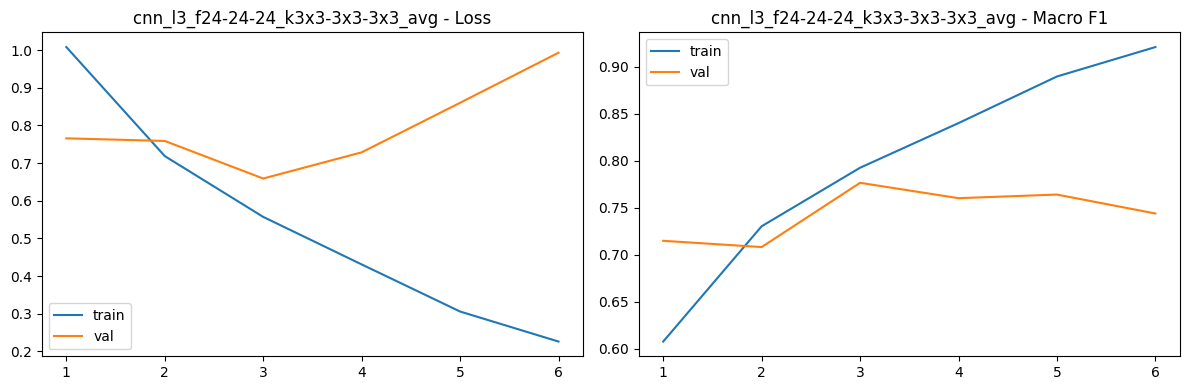

In [20]:
if not results_df.empty:
    best_model_name = results_df.iloc[0]["name"]
    best_history_path = SHARED_OUTPUT_DIR / f"{best_model_name}_history.json"
    plot_history(best_history_path, best_model_name)

### 6.4 Loss Curves for All Shared Architectures

The grid below shows the training loss and validation loss curves for every shared CNN configuration.

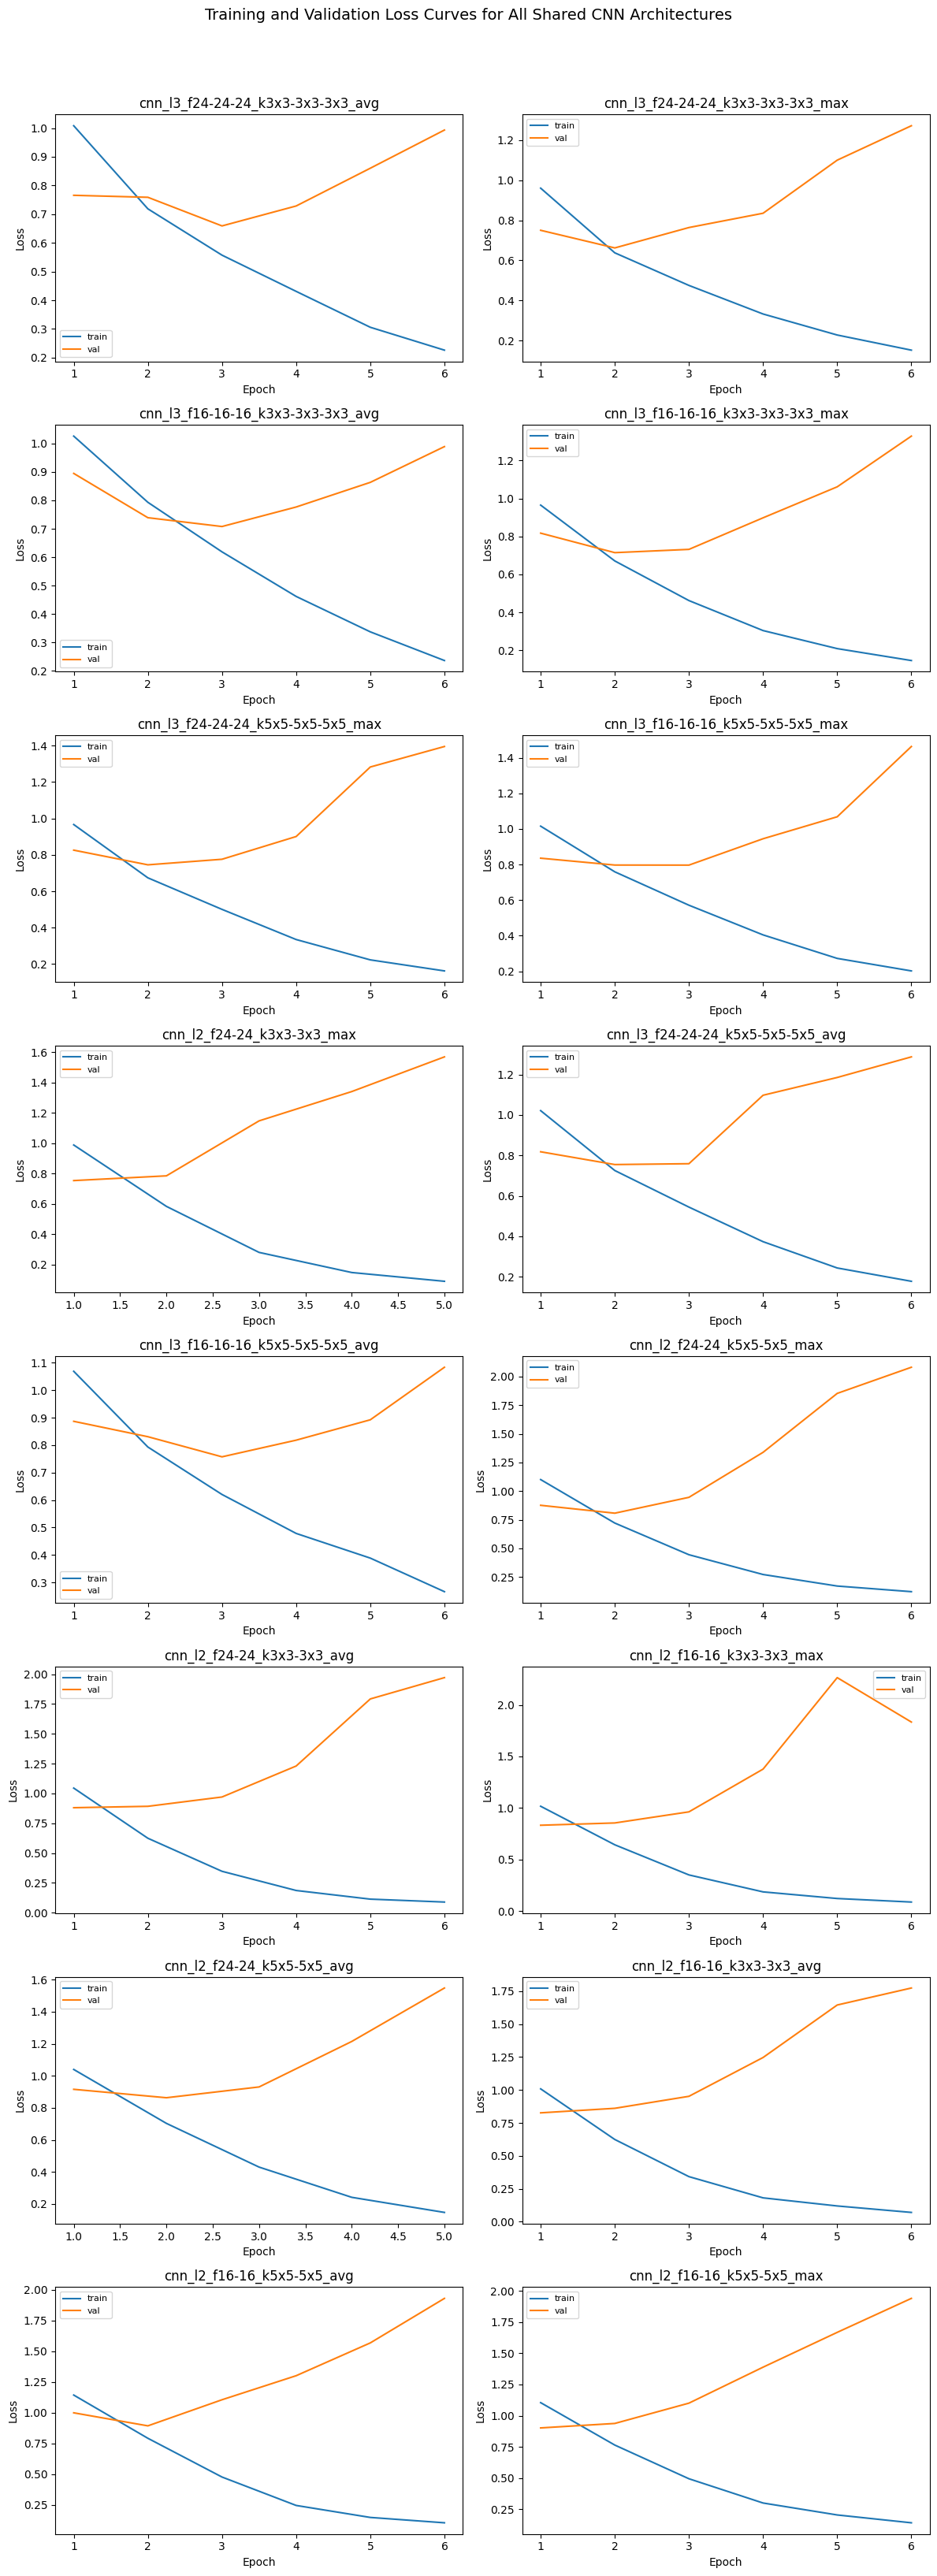

In [21]:
if not results_df.empty:
    plot_loss_grid(
        results_df["name"].tolist(),
        SHARED_OUTPUT_DIR,
        "Training and Validation Loss Curves for All Shared CNN Architectures",
        cols=2,
    )

### 6.5 Hyperparameter Analysis by Factor

The next subsections summarize the effect of each hyperparameter factor independently using the 16 trained architectures. The analysis is based on validation macro F1 and validation loss.

#### 6.5.1 Effect of the Number of Convolution Layers

This comparison isolates the effect of using 2 versus 3 convolutional layers.

In [22]:
if not results_df.empty:
    layer_summary = summarize_factor(results_df, "layers")
    layer_summary
else:
    print("No training summaries found yet.")

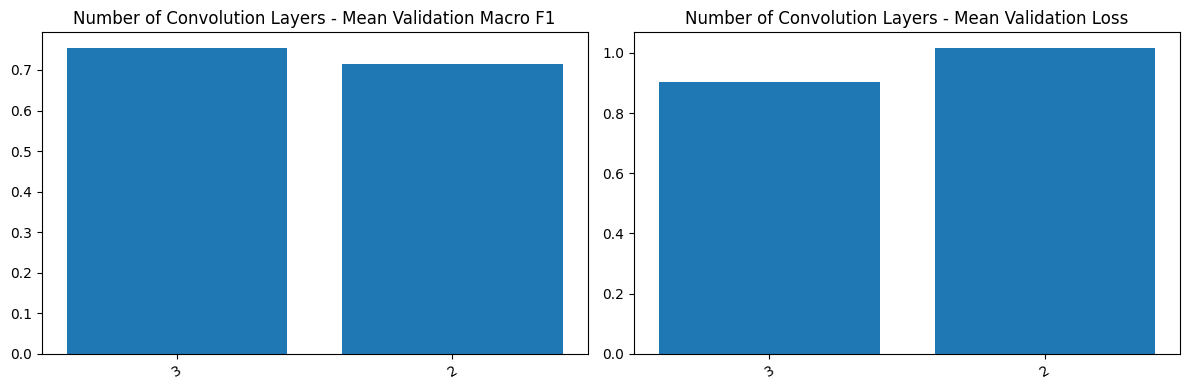

**Number of convolution layers conclusion**
- Best mean validation macro F1: `3.0` with `0.7551`.
- Lowest mean validation loss: `3.0` with `0.9041`.
- Most parameter-efficient option on average: `3.0` with `1019198` parameters.

In [23]:
if not results_df.empty:
    plot_factor_summary(layer_summary, "layers", "Number of Convolution Layers")
    display(factor_conclusion_markdown(layer_summary, "layers", "Number of convolution layers"))

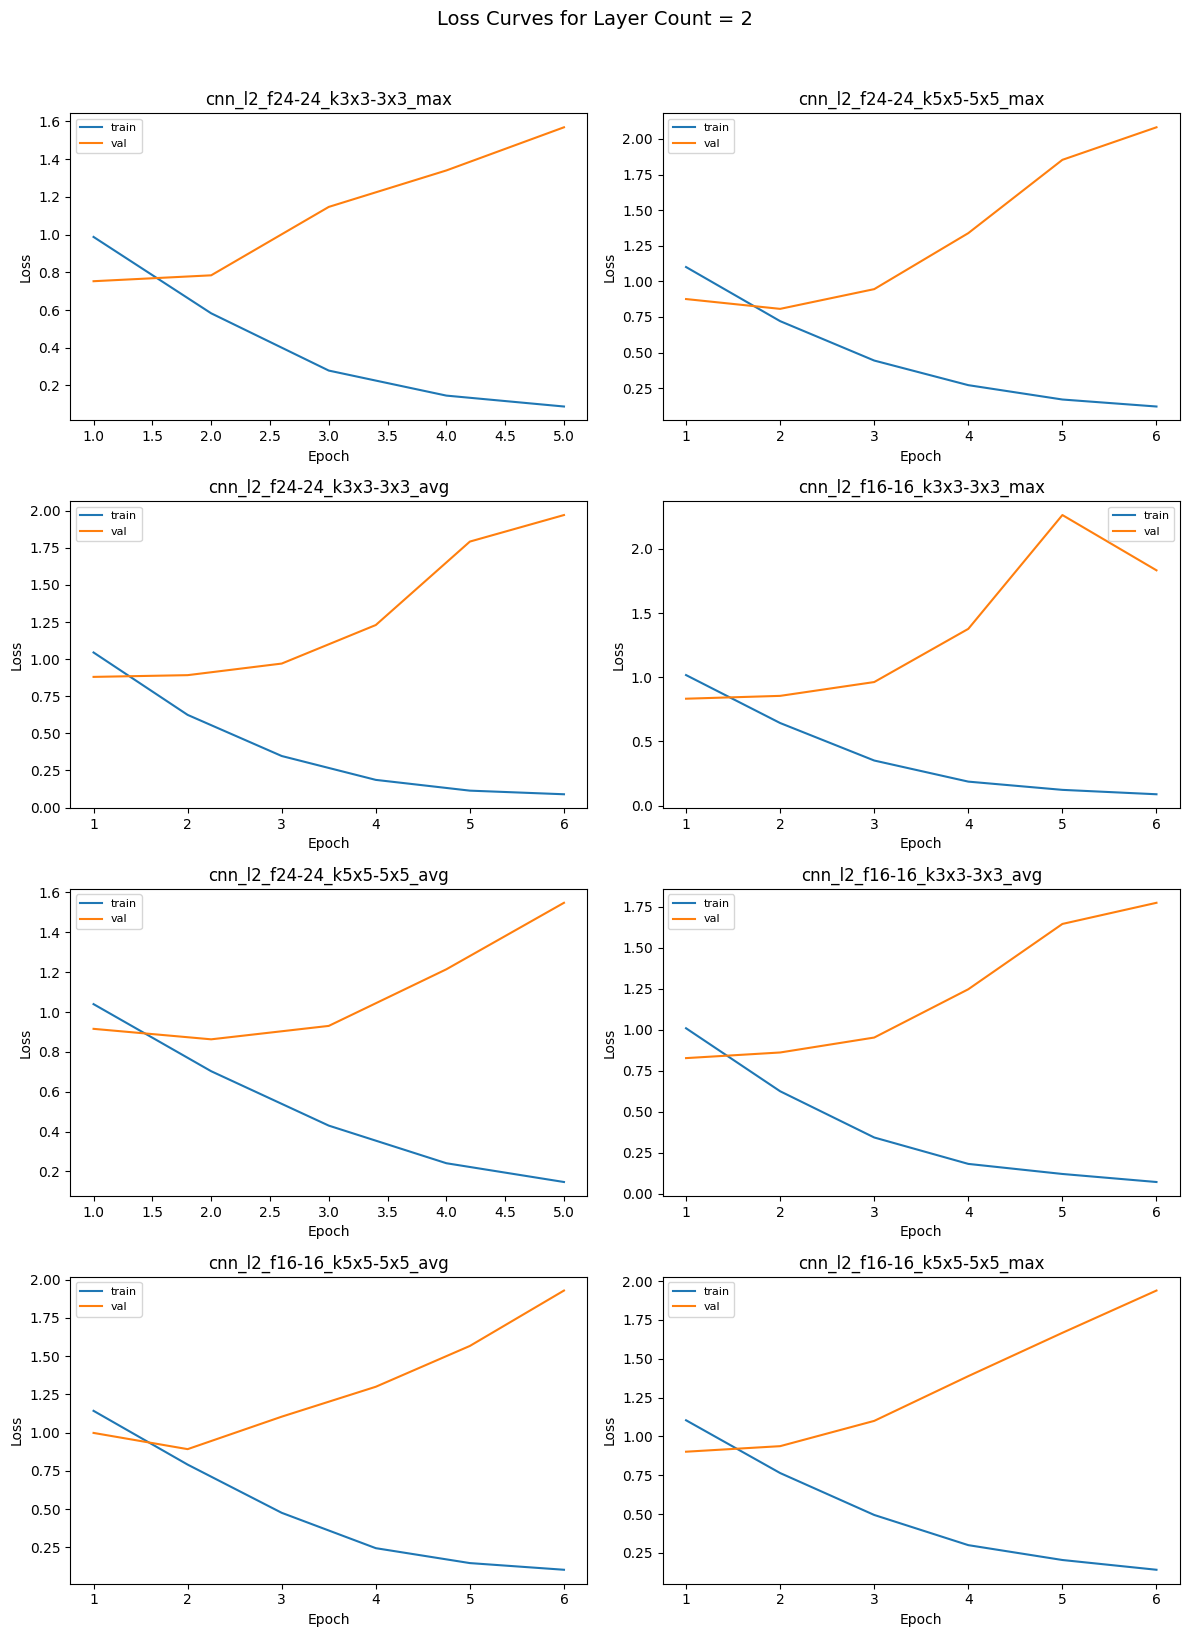

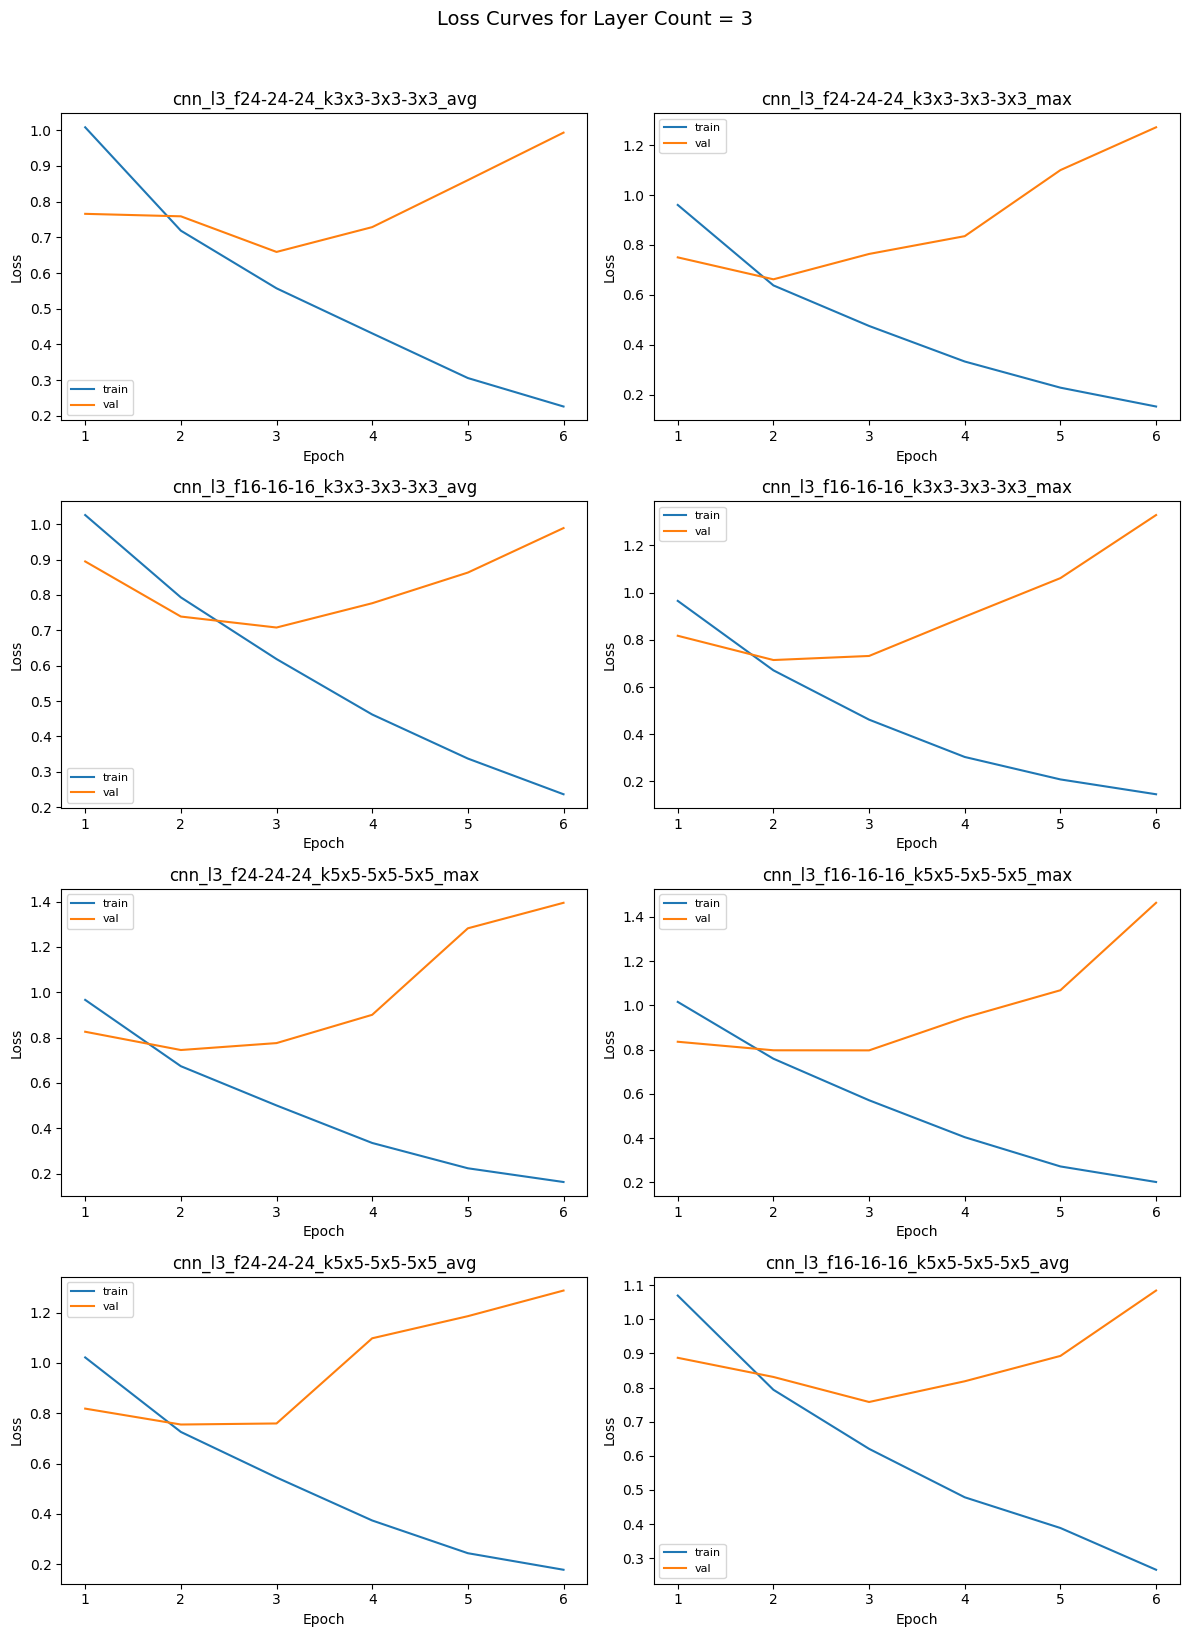

In [24]:
if not results_df.empty:
    for layer_value in sorted(results_df["layers"].unique()):
        layer_model_names = results_df.loc[results_df["layers"] == layer_value, "name"].tolist()
        plot_loss_grid(
            layer_model_names,
            SHARED_OUTPUT_DIR,
            f"Loss Curves for Layer Count = {layer_value}",
            cols=2,
        )

#### 6.5.2 Effect of the Filter Configuration

This comparison groups models by the convolution filter configuration used in each architecture.

In [25]:
if not results_df.empty:
    filter_summary = summarize_factor(results_df, "filters")
    filter_summary
else:
    print("No training summaries found yet.")

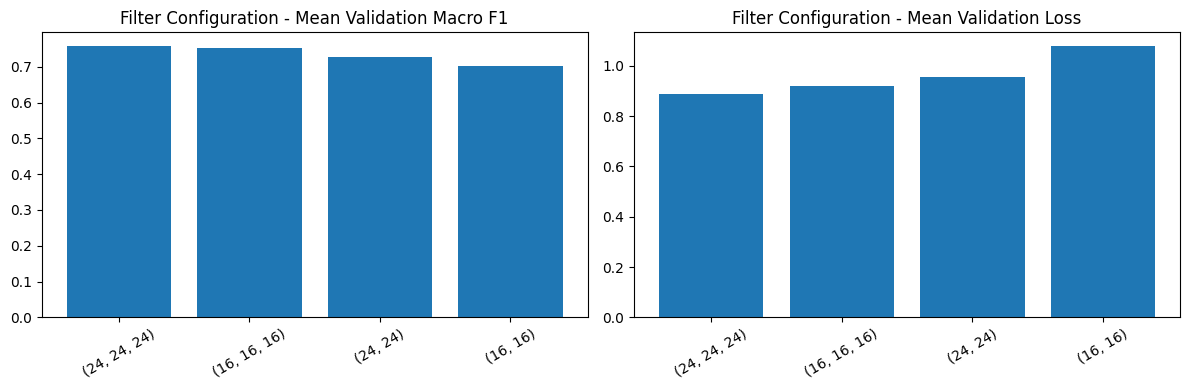

**Filter configuration conclusion**
- Best mean validation macro F1: `(24, 24, 24)` with `0.7586`.
- Lowest mean validation loss: `(24, 24, 24)` with `0.8893`.
- Most parameter-efficient option on average: `(16, 16, 16)` with `812838` parameters.

In [26]:
if not results_df.empty:
    plot_factor_summary(filter_summary, "filters", "Filter Configuration")
    display(factor_conclusion_markdown(filter_summary, "filters", "Filter configuration"))

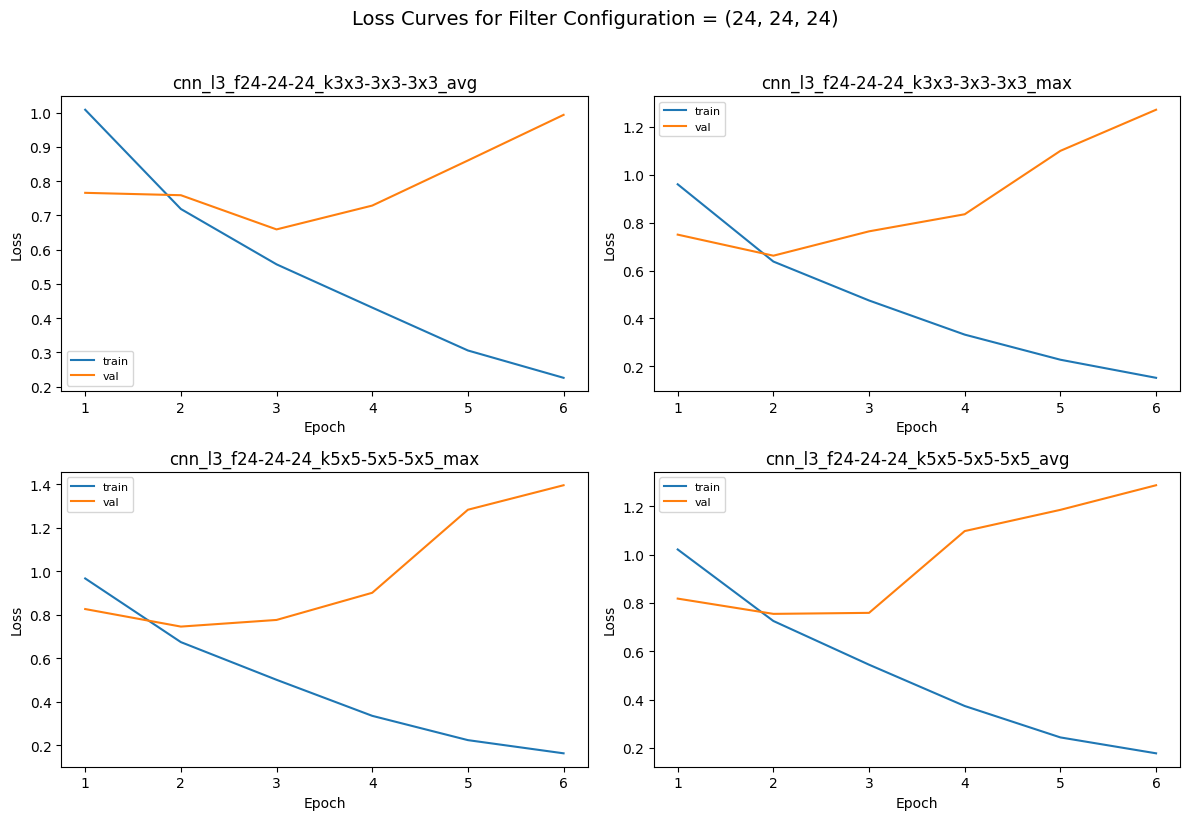

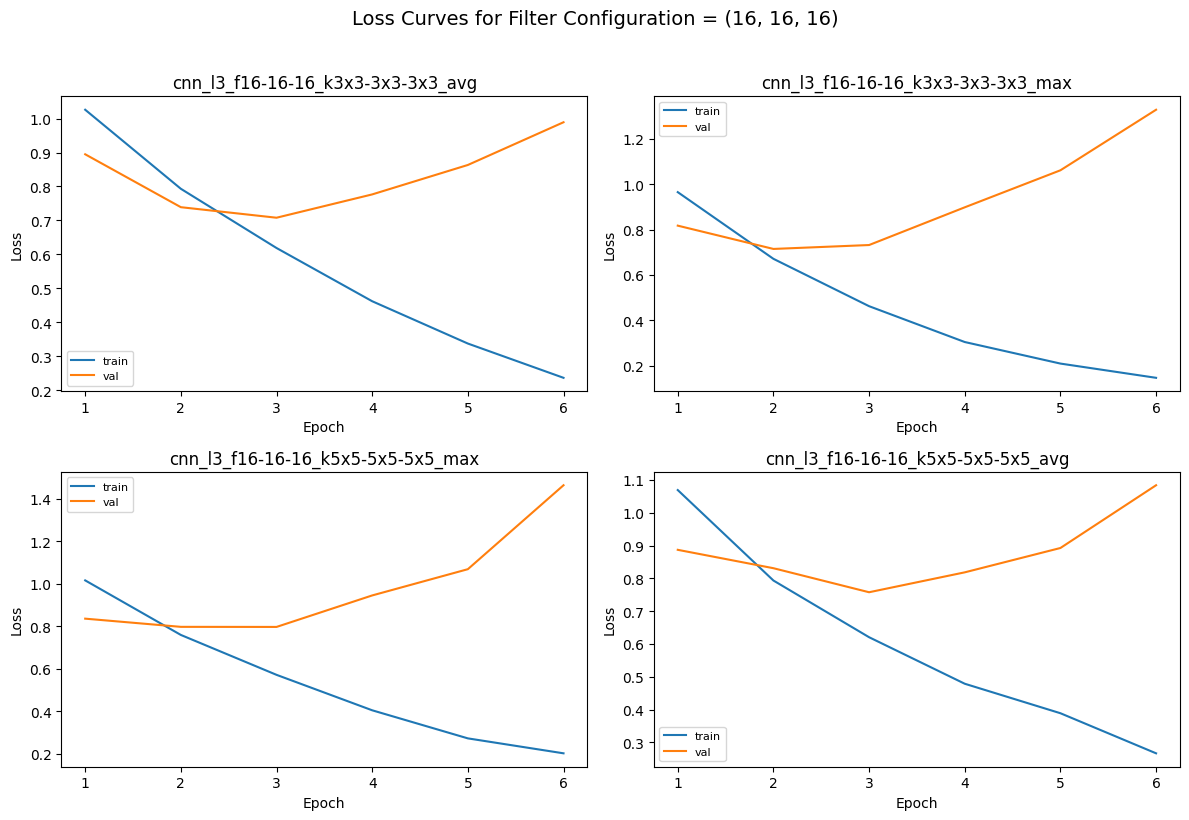

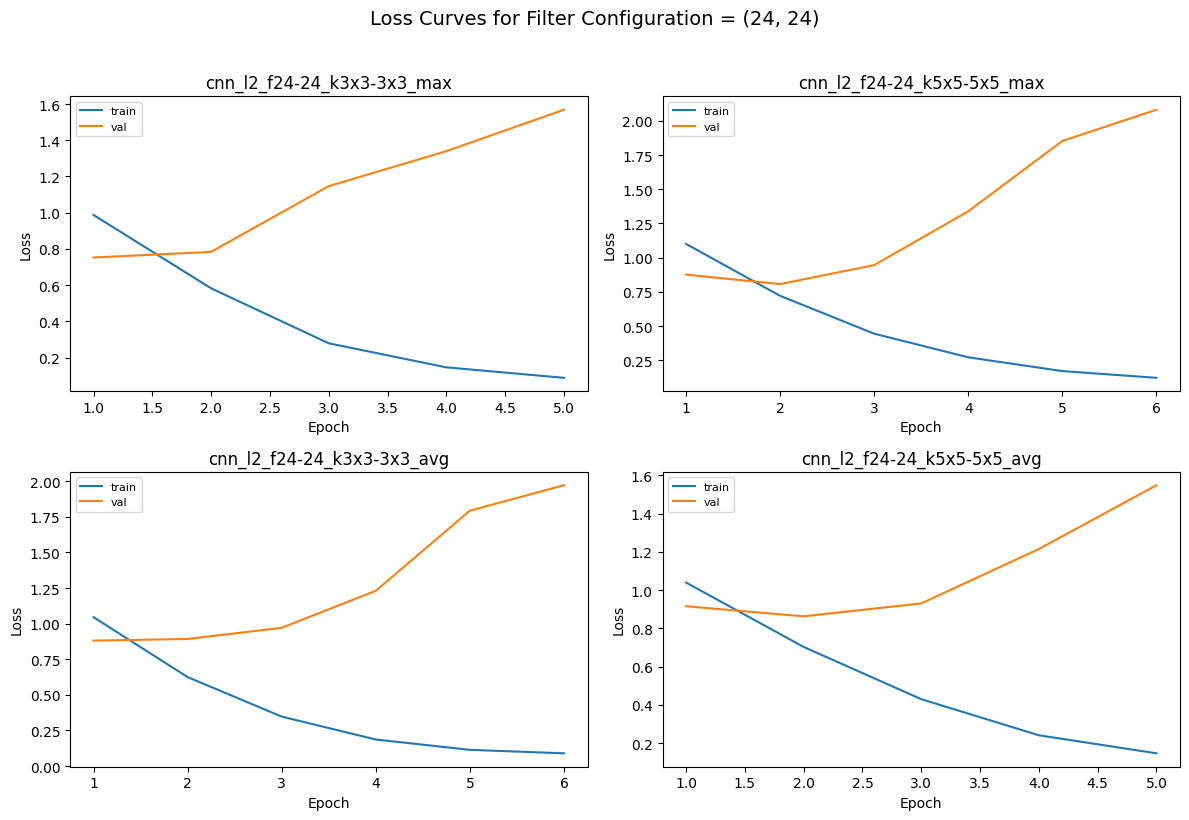

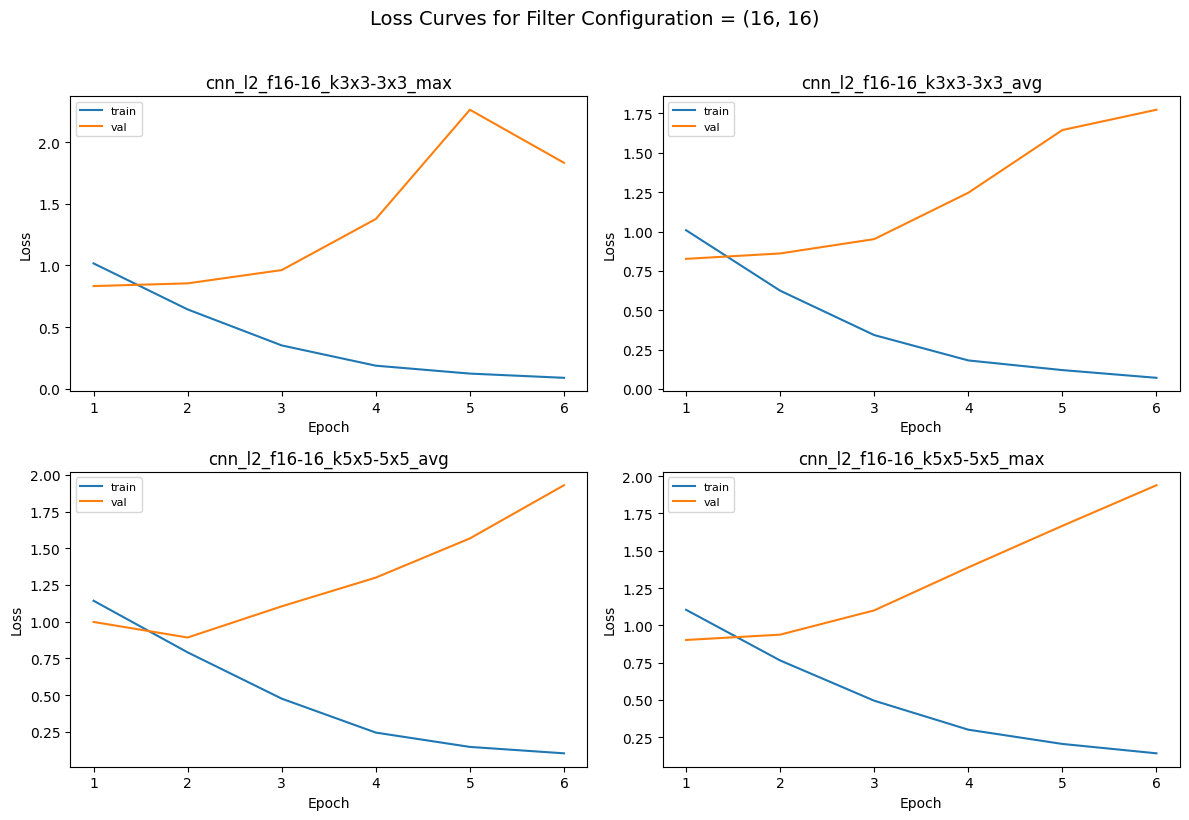

In [27]:
if not results_df.empty:
    for filter_value in filter_summary["filters"]:
        filter_model_names = results_df.loc[results_df["filters"] == filter_value, "name"].tolist()
        plot_loss_grid(
            filter_model_names,
            SHARED_OUTPUT_DIR,
            f"Loss Curves for Filter Configuration = {filter_value}",
            cols=2,
        )

#### 6.5.3 Effect of the Kernel Size Configuration

This comparison groups models by their kernel size configuration.

In [28]:
if not results_df.empty:
    kernel_summary = summarize_factor(results_df, "kernels")
    kernel_summary
else:
    print("No training summaries found yet.")

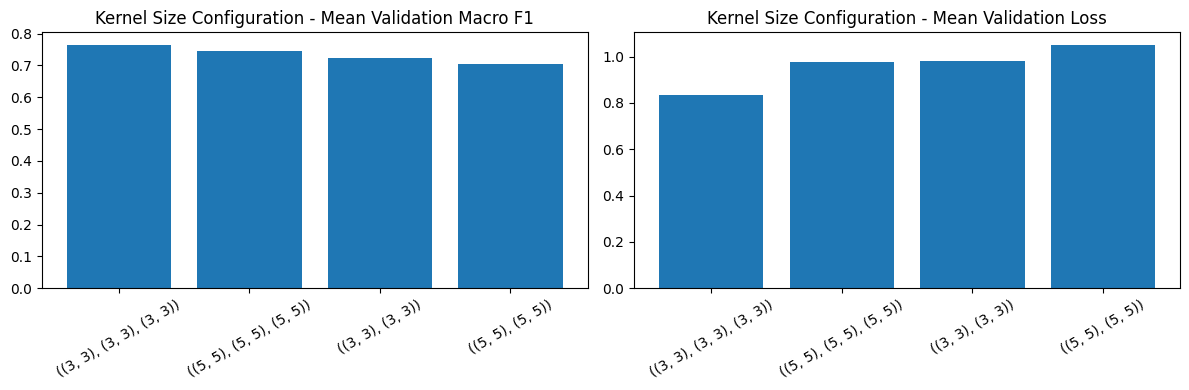

**Kernel size configuration conclusion**
- Best mean validation macro F1: `((3, 3), (3, 3), (3, 3))` with `0.7654`.
- Lowest mean validation loss: `((3, 3), (3, 3), (3, 3))` with `0.8331`.
- Most parameter-efficient option on average: `((3, 3), (3, 3), (3, 3))` with `1012062` parameters.

In [29]:
if not results_df.empty:
    plot_factor_summary(kernel_summary, "kernels", "Kernel Size Configuration")
    display(factor_conclusion_markdown(kernel_summary, "kernels", "Kernel size configuration"))

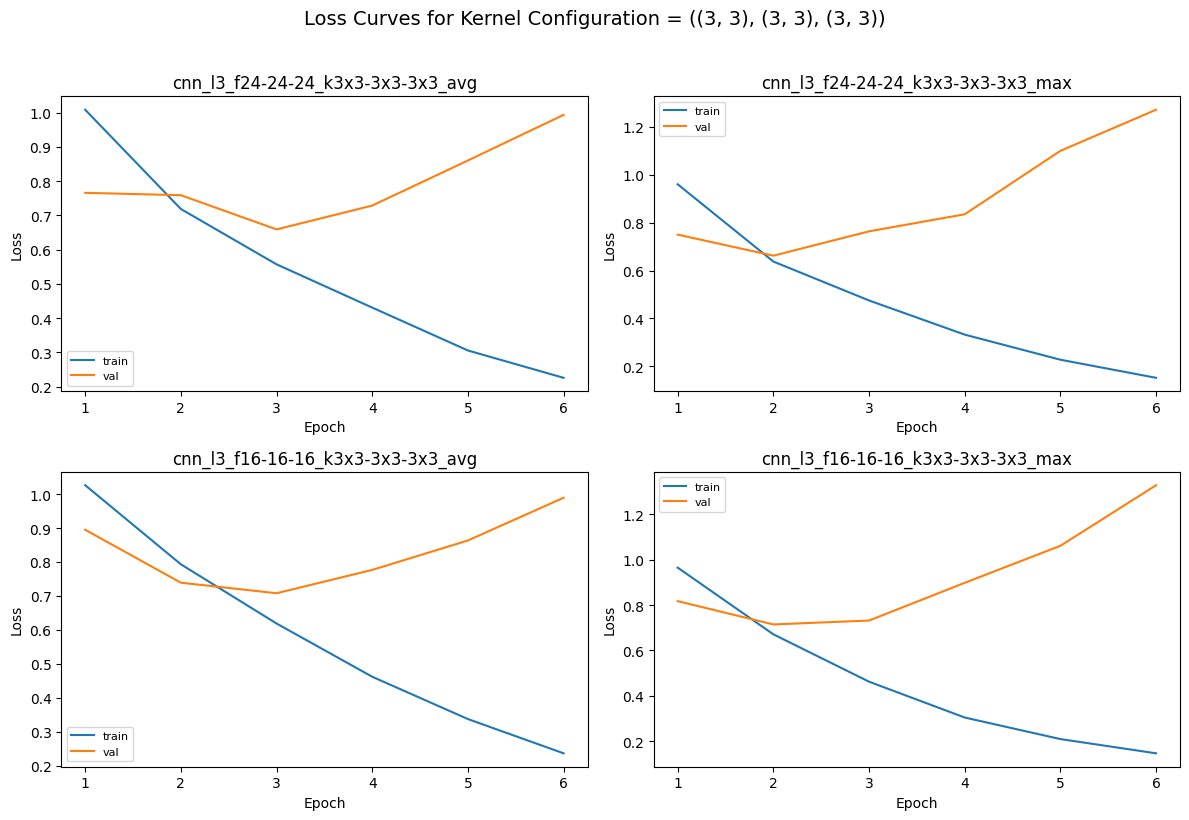

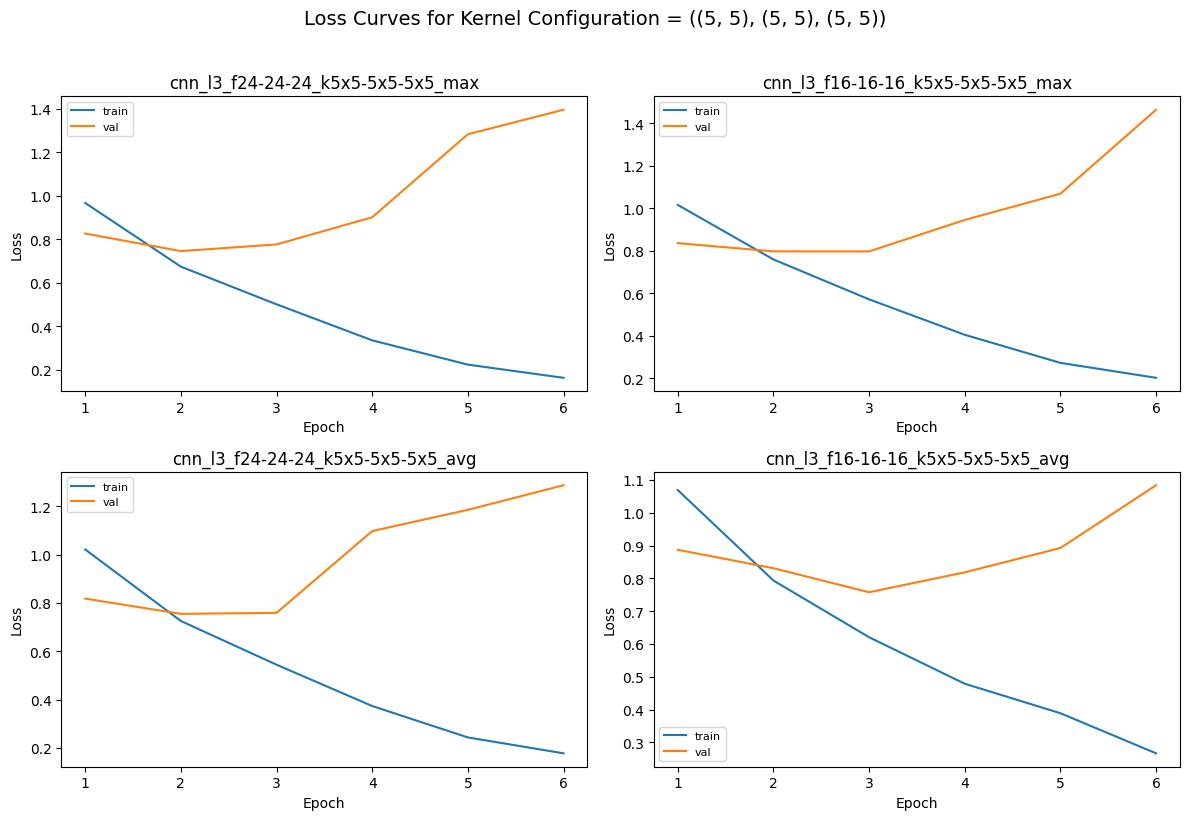

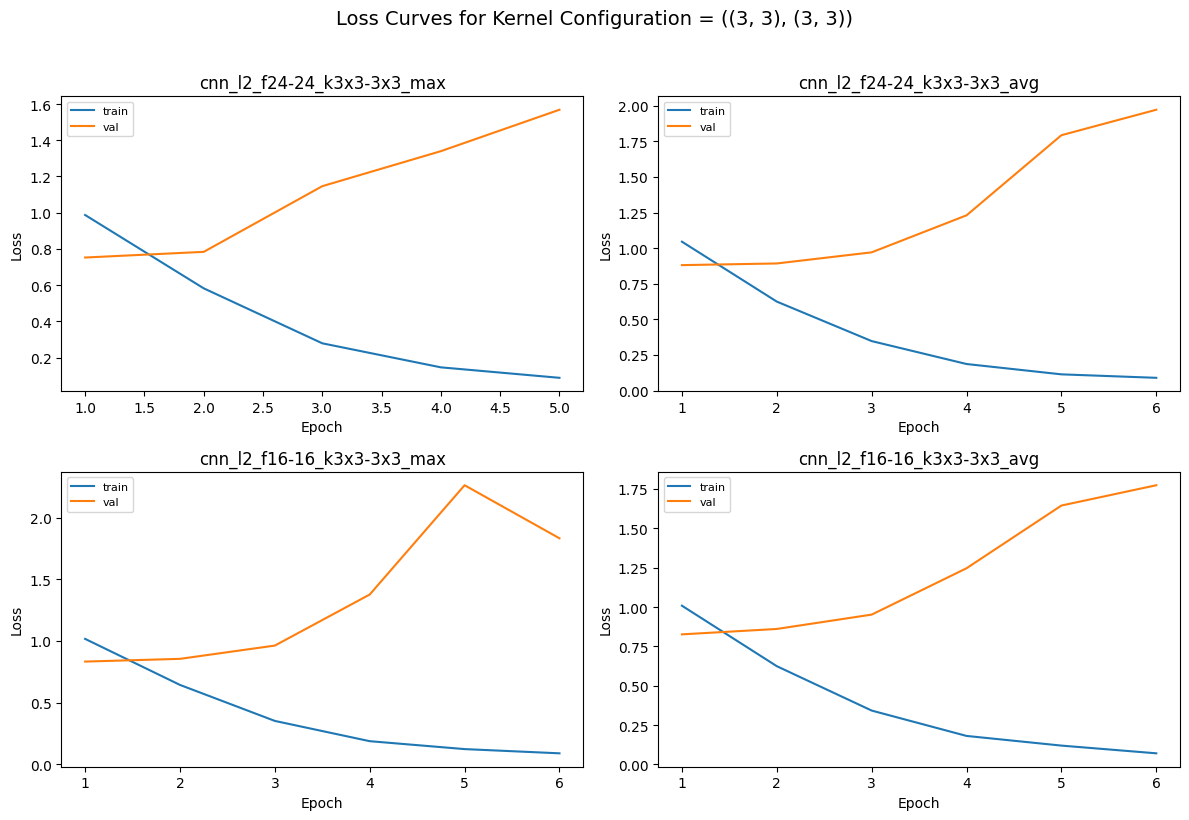

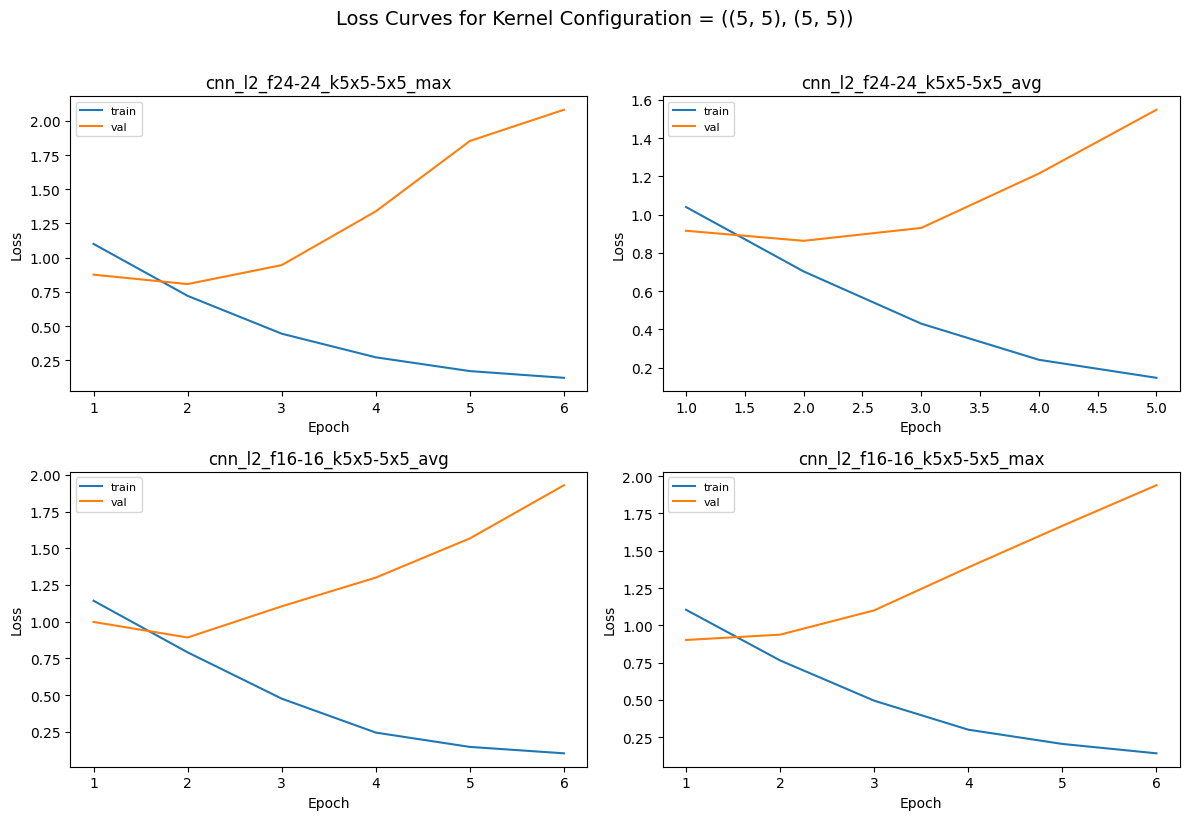

In [30]:
if not results_df.empty:
    for kernel_value in kernel_summary["kernels"]:
        kernel_model_names = results_df.loc[results_df["kernels"] == kernel_value, "name"].tolist()
        plot_loss_grid(
            kernel_model_names,
            SHARED_OUTPUT_DIR,
            f"Loss Curves for Kernel Configuration = {kernel_value}",
            cols=2,
        )

#### 6.5.4 Effect of the Pooling Type

This comparison groups models by the pooling layer variant: max pooling or average pooling.

In [31]:
if not results_df.empty:
    pooling_summary = summarize_factor(results_df, "pooling")
    pooling_summary
else:
    print("No training summaries found yet.")

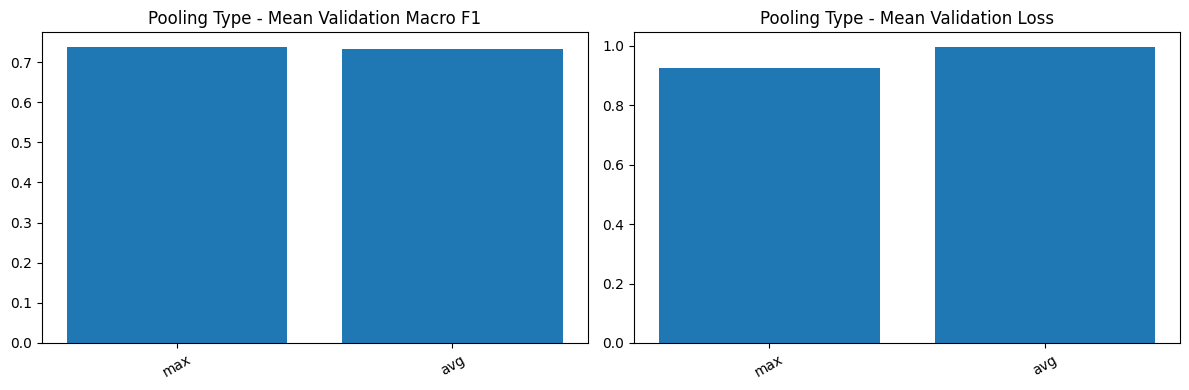

**Pooling type conclusion**
- Best mean validation macro F1: `max` with `0.7373`.
- Lowest mean validation loss: `max` with `0.9262`.
- Most parameter-efficient option on average: `max` with `2520932` parameters.

In [32]:
if not results_df.empty:
    plot_factor_summary(pooling_summary, "pooling", "Pooling Type")
    display(factor_conclusion_markdown(pooling_summary, "pooling", "Pooling type"))

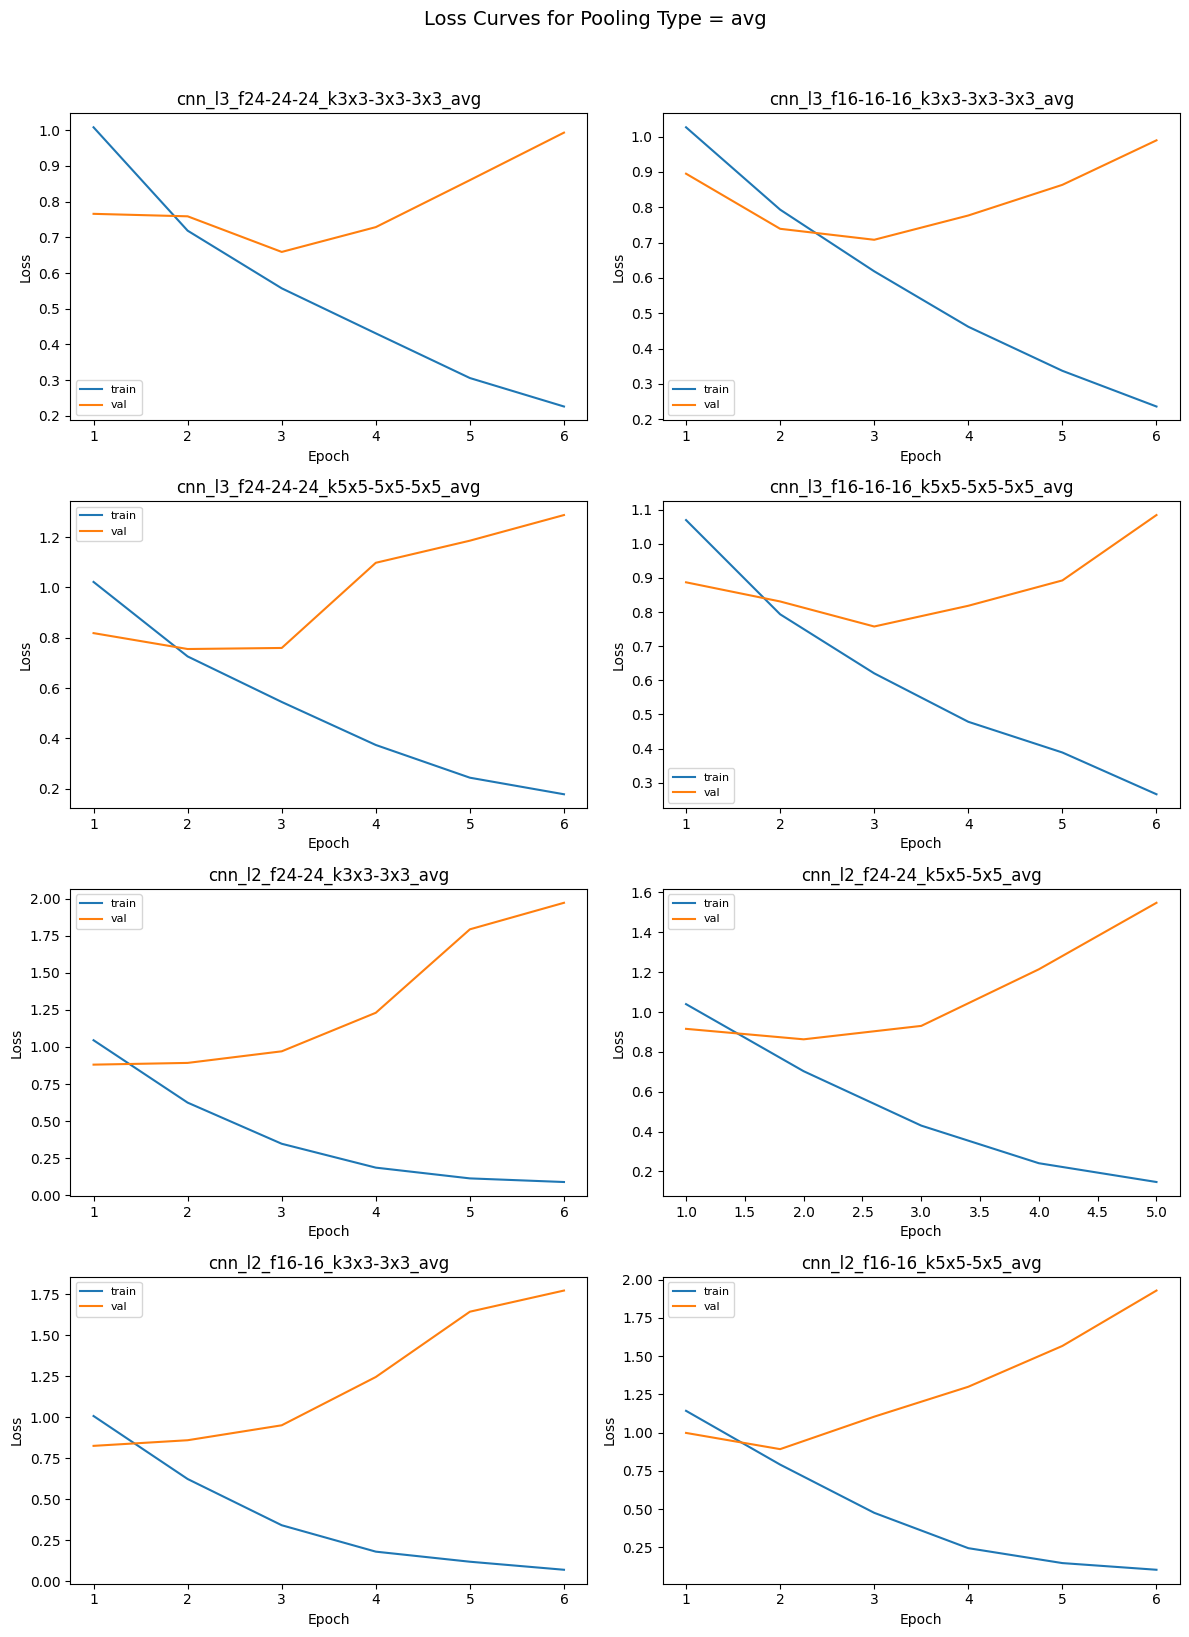

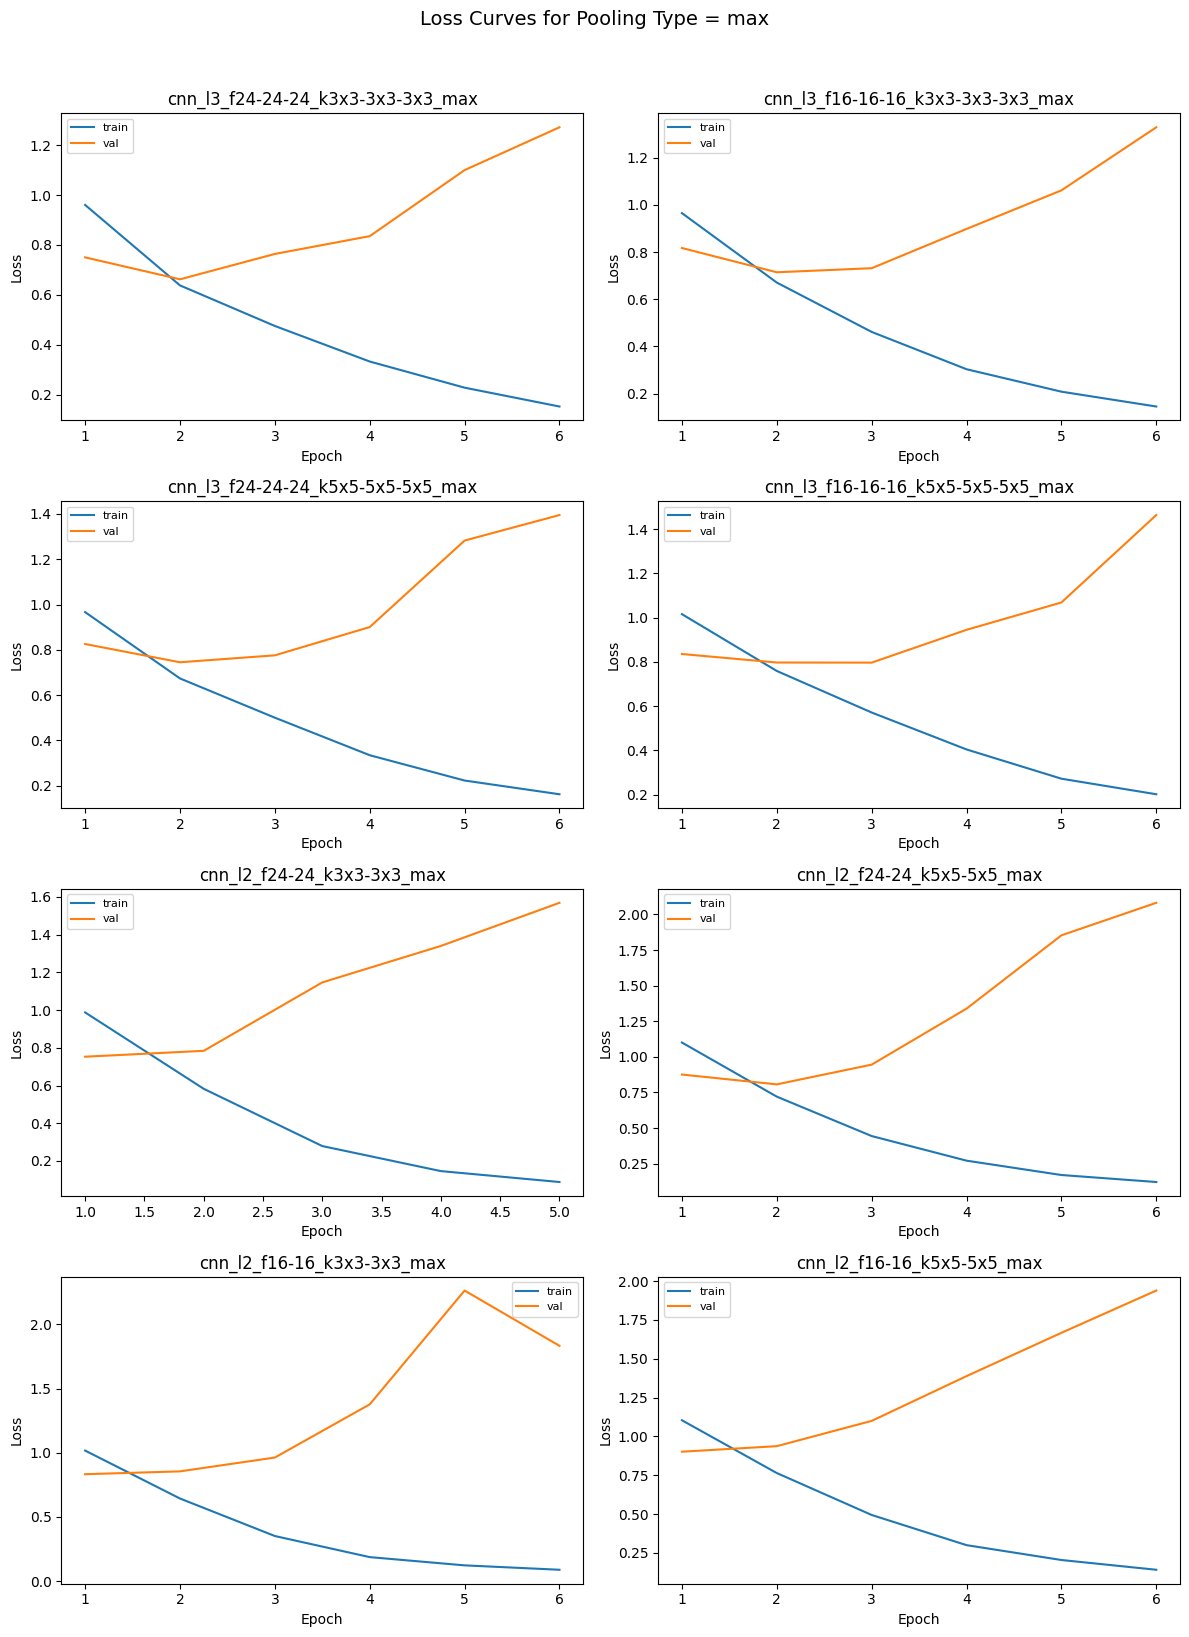

In [33]:
if not results_df.empty:
    for pooling_value in sorted(results_df["pooling"].unique()):
        pooling_model_names = results_df.loc[results_df["pooling"] == pooling_value, "name"].tolist()
        plot_loss_grid(
            pooling_model_names,
            SHARED_OUTPUT_DIR,
            f"Loss Curves for Pooling Type = {pooling_value}",
            cols=2,
        )

#### 6.5.5 Best Model per Factor Value

These tables make it easier to compare the strongest architecture found for each factor value.

In [34]:
if not results_df.empty:
    best_by_layers = results_df.sort_values("val_macro_f1", ascending=False).groupby("layers").head(1)
    best_by_filters = results_df.sort_values("val_macro_f1", ascending=False).groupby("filters").head(1)
    best_by_kernels = results_df.sort_values("val_macro_f1", ascending=False).groupby("kernels").head(1)
    best_by_pooling = results_df.sort_values("val_macro_f1", ascending=False).groupby("pooling").head(1)

    display(best_by_layers[["name", "layers", "val_macro_f1", "val_loss", "params"]].sort_values("layers"))
    display(best_by_filters[["name", "filters", "val_macro_f1", "val_loss", "params"]].sort_values("val_macro_f1", ascending=False))
    display(best_by_kernels[["name", "kernels", "val_macro_f1", "val_loss", "params"]].sort_values("val_macro_f1", ascending=False))
    display(best_by_pooling[["name", "pooling", "val_macro_f1", "val_loss", "params"]].sort_values("pooling"))
else:
    print("No training summaries found yet.")

,name,layers,val_macro_f1,val_loss,params
5,cnn_l2_f24-24_k3x3-3x3_max,2,0.747918,0.783844,4823230
12,cnn_l3_f24-24-24_k3x3-3x3-3x3_avg,3,0.776496,0.659108,1215766


,name,filters,val_macro_f1,val_loss,params
12,cnn_l3_f24-24-24_k3x3-3x3-3x3_avg,"(24, 24, 24)",0.776496,0.659108,1215766
8,cnn_l3_f16-16-16_k3x3-3x3-3x3_avg,"(16, 16, 16)",0.764288,0.776668,808358
5,cnn_l2_f24-24_k3x3-3x3_max,"(24, 24)",0.747918,0.783844,4823230
1,cnn_l2_f16-16_k3x3-3x3_max,"(16, 16)",0.720193,0.962783,3214486


,name,kernels,val_macro_f1,val_loss,params
12,cnn_l3_f24-24-24_k3x3-3x3-3x3_avg,"((3, 3), (3, 3), (3, 3))",0.776496,0.659108,1215766
15,cnn_l3_f24-24-24_k5x5-5x5-5x5_max,"((5, 5), (5, 5), (5, 5))",0.748608,0.775718,1235350
5,cnn_l2_f24-24_k3x3-3x3_max,"((3, 3), (3, 3))",0.747918,0.783844,4823230
7,cnn_l2_f24-24_k5x5-5x5_max,"((5, 5), (5, 5))",0.725501,0.945574,4833598


,name,pooling,val_macro_f1,val_loss,params
12,cnn_l3_f24-24-24_k3x3-3x3-3x3_avg,avg,0.776496,0.659108,1215766
13,cnn_l3_f24-24-24_k3x3-3x3-3x3_max,max,0.767425,0.835253,1215766


### 6.6 Prediction Comparison Across Hyperparameter Variations

The following tables compare final class predictions on the same small test subset using the strongest model found for each factor value.

In [35]:
if not results_df.empty:
    layer_prediction_table = build_prediction_comparison_table(
        best_by_layers["name"].tolist(),
        dataset.test,
        dataset.class_names,
        IMAGE_SIZE,
        SHARED_OUTPUT_DIR,
        sample_count=6,
    )
    layer_prediction_table

E0000 00:00:1778771353.068846    1060 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


I0000 00:00:1778771354.377776    1139 cuda_dnn.cc:461] Loaded cuDNN version 92200


E0000 00:00:1778771528.360242    1060 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [36]:
if not results_df.empty:
    filter_prediction_table = build_prediction_comparison_table(
        best_by_filters["name"].tolist(),
        dataset.test,
        dataset.class_names,
        IMAGE_SIZE,
        SHARED_OUTPUT_DIR,
        sample_count=6,
    )
    filter_prediction_table

E0000 00:00:1778771535.674170    1060 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [37]:
if not results_df.empty:
    kernel_prediction_table = build_prediction_comparison_table(
        best_by_kernels["name"].tolist(),
        dataset.test,
        dataset.class_names,
        IMAGE_SIZE,
        SHARED_OUTPUT_DIR,
        sample_count=6,
    )
    kernel_prediction_table

E0000 00:00:1778771539.234049    1060 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [38]:
if not results_df.empty:
    pooling_prediction_table = build_prediction_comparison_table(
        best_by_pooling["name"].tolist(),
        dataset.test,
        dataset.class_names,
        IMAGE_SIZE,
        SHARED_OUTPUT_DIR,
        sample_count=6,
    )
    pooling_prediction_table

### 6.7 Best Model Architecture Summary

The best-performing shared CNN is loaded again so its final architecture and layer-level configuration can be reviewed directly.

In [39]:
if not results_df.empty:
    best_model_name = results_df.iloc[0]["name"]
    best_model = load_saved_classifier(SHARED_OUTPUT_DIR, best_model_name, compile=False)
    best_model.summary()
    pd.DataFrame(summarize_model_layers(best_model))

Model: "cnn_l3_f24-24-24_k3x3-3x3-3x3_avg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv (Conv2D)            │ (None, 224, 224, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (AveragePooling2D)  │ (None, 112, 112, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 112, 112, 24)   │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (AveragePooling2D)  │ (None, 56, 56, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv (Conv2D)            │ (None, 56, 56, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (AveragePooling2D)  │ (None, 28, 28, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     1,204,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,215,766 (4.64 MB)

 Trainable params: 1,215,766 (4.64 MB)

 Non-trainable params: 0 (0.00 B)

---
# 7. Feature Extractor Demo

The `extract_and_save_features` utility is tested with a frozen Keras encoder.
This demo uses the penultimate-layer representation from the best trained shared model.

### 7.1 Frozen Encoder Check

This is a lightweight demonstration that the feature extraction pipeline works as required and saves the resulting features to disk as `.npy`.

In [40]:
if results_df.empty:
    print("Train the shared sweep first before running the feature extractor demo.")
else:
    best_model_name = results_df.iloc[0]["name"]
    best_model = load_saved_classifier(SHARED_OUTPUT_DIR, best_model_name, compile=False)
    _ = best_model(np.zeros((1,) + INPUT_SHAPE, dtype=np.float32), training=False)

    encoder = tf.keras.Model(
        inputs=best_model.inputs,
        outputs=best_model.get_layer("dense_1").output,
        name=f"{best_model.name}_encoder",
    )
    encoder.trainable = False

    demo_features = extract_and_save_features(
        image_paths=dataset.test.image_paths[:16],
        encoder=encoder,
        target_size=IMAGE_SIZE,
        output_path=FEATURE_DEMO_PATH,
        batch_size=8,
    )
    print("Saved feature file:", FEATURE_DEMO_PATH)
    print("Feature shape:", demo_features.shape)

E0000 00:00:1778771544.632272    1060 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Saved feature file: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/artifacts/cnn/reports/demo_encoder_features.npy
Feature shape: (16, 64)


---
# 8. Training Outputs

Main outputs from this notebook:
- final models: `artifacts/cnn/shared/*_final.keras`
- final weights: `artifacts/cnn/shared/*.weights.h5`
- best-weight checkpoints: `artifacts/cnn/shared/weights/*.weights.h5`
- training history: `artifacts/cnn/shared/*_history.json`
- experiment summaries: `artifacts/cnn/shared/*_summary.json`